Name and ID:

Ahmad Al-oqdeh - 202310777 

Project Title: Heart Disease Prediction using Machine Learning

Instructor: Dr. Hossam Mustafa

# Importing Libaries

In [23]:
# Import tools we need
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

# Preprocessing

In [24]:
# Load the dataset
df = pd.read_csv('C:\\Users\\Admin\\OneDrive\\Desktop\\machine learning\\project\\Heart Prediction Quantum Dataset.csv')
print("Dataset loaded successfully!\n")
print(df.head())  # quick look at first rows


Dataset loaded successfully!

   Age  Gender  BloodPressure  Cholesterol  HeartRate  QuantumPatternFeature  \
0   68       1            105          191        107               8.362241   
1   58       0             97          249         89               9.249002   
2   44       0             93          190         82               7.942542   
3   72       1             93          183        101               6.495155   
4   37       0            145          166        103               7.653900   

   HeartDisease  
0             1  
1             0  
2             1  
3             1  
4             1  


In [25]:
# Handle missing values
# Numbers → fill with median
# Categories → fill with most common value
num_cols = ['Age', 'BloodPressure', 'Cholesterol', 'HeartRate', 'QuantumPatternFeature']
cat_cols = ['Gender']

for col in num_cols:
    df[col].fillna(df[col].median(), inplace=True)

for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

print("Missing values handled.\n")


Missing values handled.



In [26]:
# Scale numeric features
# We scale: Age, Cholesterol, HeartRate, QuantumPatternFeature
# BloodPressure is not scaled because we will turn it into categories
scaler = StandardScaler()
scaled_cols = ['Age', 'Cholesterol', 'HeartRate', 'QuantumPatternFeature']
df[scaled_cols] = scaler.fit_transform(df[scaled_cols])

print("Features scaled.\n")


Features scaled.



In [27]:
# Convert Blood Pressure into categories
# Instead of raw numbers → group into Low, Normal, High, VeryHigh
bins = [0, 90, 120, 140, 200]
labels = ['Low', 'Normal', 'High', 'VeryHigh']
df['BP_Category'] = pd.cut(df['BloodPressure'], bins=bins, labels=labels)

# One-hot encode categories into 0/1 columns
df = pd.get_dummies(df, columns=['BP_Category'], prefix='BP')

# Drop original BloodPressure
df.drop('BloodPressure', axis=1, inplace=True)
print("Blood Pressure categorized and encoded.\n")


Blood Pressure categorized and encoded.



In [28]:
# Split dataset into train (75%) and test (25%)
X = df.drop('HeartDisease', axis=1)  # features
y = df['HeartDisease']               # target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
print(f"Data split into {X_train.shape[0]} training rows and {X_test.shape[0]} testing rows.\n")


Data split into 375 training rows and 125 testing rows.



# models to compare

In [29]:
# Train different models
# We will try Logistic Regression, Decision Tree, Random Forest, and SVM
models = {
    "Logistic Regression": LogisticRegression(random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "SVM": SVC(probability=True, random_state=42)
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)                # train the model
    y_pred = model.predict(X_test)             # test the model
    y_pred_proba = model.predict_proba(X_test)[:, 1]  # needed for AUC

    # Save metrics
    results.append([
        name,
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred),
        recall_score(y_test, y_pred),
        f1_score(y_test, y_pred),
        roc_auc_score(y_test, y_pred_proba)
    ])

print("Models trained and evaluated.\n")


Models trained and evaluated.



# Show performance comparison table

In [30]:
# Show comparison of models
results_df = pd.DataFrame(results, columns=["Algorithm", "Accuracy", "Precision", "Recall", "F1-Score", "AUC"])
print("Performance Comparison:\n")
print(results_df.round(4))

# Save to CSV for the report
results_df.to_csv('heart_disease_results.csv', index=False)


Performance Comparison:

             Algorithm  Accuracy  Precision  Recall  F1-Score     AUC
0  Logistic Regression     0.928     0.9710  0.9054    0.9371  0.9820
1        Decision Tree     0.912     0.9437  0.9054    0.9241  0.9135
2        Random Forest     0.920     0.9706  0.8919    0.9296  0.9748
3                  SVM     0.920     0.9571  0.9054    0.9306  0.9698


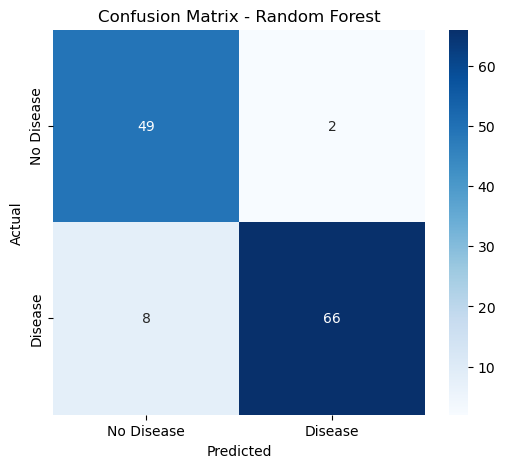

In [31]:
# Confusion Matrix for Random Forest
# Random Forest usually performs best, so let's check its predictions
best_model = RandomForestClassifier(random_state=42)
best_model.fit(X_train, y_train)
y_pred_rf = best_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Disease', 'Disease'],
            yticklabels=['No Disease', 'Disease'])
plt.title('Confusion Matrix - Random Forest')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


# conclusion

In [32]:
# Final Conclusion
# Find the best model based on F1-Score (balance between precision & recall)
best_row = results_df.loc[results_df['F1-Score'].idxmax()]
print("\nFinal Conclusion:")
print(f"Best Model → {best_row['Algorithm']}")
print(f"Accuracy: {best_row['Accuracy']:.4f}, F1-Score: {best_row['F1-Score']:.4f}, AUC: {best_row['AUC']:.4f}")

# Explain in simple words which model won
if best_row['Algorithm'] == 'Logistic Regression':
    print("Logistic Regression shows the data has a clear linear pattern.")
elif best_row['Algorithm'] == 'Random Forest':
    print("Random Forest handles complex patterns well and gives reliable predictions.")
elif best_row['Algorithm'] == 'Decision Tree':
    print("Decision Tree caught most disease cases but gave more false alarms.")
else:
    print("SVM worked well in high-risk detection but may need more tuning.")



Final Conclusion:
Best Model → Logistic Regression
Accuracy: 0.9280, F1-Score: 0.9371, AUC: 0.9820
Logistic Regression shows the data has a clear linear pattern.
